<a href="https://colab.research.google.com/github/AlokROfficial/ADBMS/blob/main/AI_final.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
pip install scikit-fuzzy numpy pandas matplotlib scikit-learn ucimlrepo

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 920.8/920.8 kB 24.6 MB/s eta 0:00:00


In [3]:
pip install networkx

In [4]:
import numpy as np
import pandas as pd
import skfuzzy as fuzz
from skfuzzy import control as ctrl
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from ucimlrepo import fetch_ucirepo

# Load dataset directly from UCI
dataset = fetch_ucirepo(id=468)
df = dataset.data.features.copy()
df['Revenue'] = dataset.data.targets['Revenue'].astype(int)

print(df.shape)        # (12330, 18)
print(df['Revenue'].value_counts())  # ~10,422 False, ~1,908 True
print(df[['PageValues', 'BounceRates', 'ProductRelated_Duration']].describe())

(12330, 18)
Revenue
0    10422
1     1908
Name: count, dtype: int64
         PageValues   BounceRates  ProductRelated_Duration
count  12330.000000  12330.000000             12330.000000
mean       5.889258      0.022191              1194.746220
std       18.568437      0.048488              1913.669288
min        0.000000      0.000000                 0.000000
25%        0.000000      0.000000               184.137500
50%        0.000000      0.003112               598.936905
75%        0.000000      0.016813              1464.157214
max      361.763742      0.200000             63973.522230


In [5]:
# Select the three fuzzy input features + label
features = ['PageValues', 'BounceRates', 'ProductRelated_Duration']

# Check ranges to set universe of discourse correctly
for f in features:
    print(f"{f}: min={df[f].min():.2f}, max={df[f].max():.2f}, "
          f"mean={df[f].mean():.2f}, median={df[f].median():.2f}")

# Output (approximate):
# PageValues: min=0.00, max=361.76, mean=5.99, median=0.00
# BounceRates: min=0.00, max=0.20, mean=0.022, median=0.003
# ProductRelated_Duration: min=0.00, max=63973.52, mean=1194.75

# Cap outliers using 99th percentile to define upper universe boundary
pv_max   = df['PageValues'].quantile(0.99)               # ~87
br_max   = df['BounceRates'].quantile(0.99)              # ~0.15
dur_max  = df['ProductRelated_Duration'].quantile(0.99)  # ~5000

# Clip values to the universe range
df['PageValues']               = df['PageValues'].clip(0, pv_max)
df['BounceRates']              = df['BounceRates'].clip(0, br_max)
df['ProductRelated_Duration']  = df['ProductRelated_Duration'].clip(0, dur_max)


PageValues: min=0.00, max=361.76, mean=5.89, median=0.00
BounceRates: min=0.00, max=0.20, mean=0.02, median=0.00
ProductRelated_Duration: min=0.00, max=63973.52, mean=1194.75, median=598.94


In [6]:
# ── Universe of discourse ──────────────────────────────────────────────────
pv_universe  = np.arange(0, pv_max + 1, 0.5)
br_universe  = np.arange(0, br_max + 0.001, 0.001)
dur_universe = np.arange(0, dur_max + 10, 10)
score_univ   = np.arange(0, 101, 1)

# ── Antecedents (inputs) and Consequent (output) ──────────────────────────
page_value  = ctrl.Antecedent(pv_universe,  'page_value')
bounce_rate = ctrl.Antecedent(br_universe,  'bounce_rate')
duration    = ctrl.Antecedent(dur_universe, 'duration')
intent      = ctrl.Consequent(score_univ,   'intent')

# ── Membership functions — trimf = triangular, trapmf = trapezoidal ────────
# PageValues: most sessions are 0, so low is a wide trapezoid on the left
page_value['low']    = fuzz.trapmf(pv_universe,  [0,  0,  5,  20])
page_value['medium'] = fuzz.trimf(pv_universe,   [10, 35, 60])
page_value['high']   = fuzz.trapmf(pv_universe,  [45, 65, pv_max, pv_max])

# BounceRates: low bounce = engaged visitor
bounce_rate['low']    = fuzz.trapmf(br_universe, [0,    0,    0.02, 0.06])
bounce_rate['medium'] = fuzz.trimf(br_universe,  [0.03, 0.07, 0.11])
bounce_rate['high']   = fuzz.trapmf(br_universe, [0.08, 0.12, br_max, br_max])

# ProductRelated_Duration: time spent on product pages
duration['low']    = fuzz.trapmf(dur_universe, [0,    0,    200,  700])
duration['medium'] = fuzz.trimf(dur_universe,  [400,  1500, 3000])
duration['high']   = fuzz.trapmf(dur_universe, [2000, 3500, dur_max, dur_max])

# Output: purchase intent score (0–100)
intent['very_low']  = fuzz.trapmf(score_univ, [0,  0,  10, 25])
intent['low']       = fuzz.trimf(score_univ,  [15, 30, 45])
intent['medium']    = fuzz.trimf(score_univ,  [35, 50, 65])
intent['high']      = fuzz.trimf(score_univ,  [55, 70, 85])
intent['very_high'] = fuzz.trapmf(score_univ, [75, 90, 100, 100])

# ── Rule base (27 rules: all combinations of 3 inputs × 3 sets) ───────────
# Key insight: high page value + low bounce + high duration = very high intent
rules = [
  # High page value rules
  ctrl.Rule(page_value['high'] & bounce_rate['low']    & duration['high'],   intent['very_high']),
  ctrl.Rule(page_value['high'] & bounce_rate['low']    & duration['medium'], intent['very_high']),
  ctrl.Rule(page_value['high'] & bounce_rate['low']    & duration['low'],    intent['high']),
  ctrl.Rule(page_value['high'] & bounce_rate['medium'] & duration['high'],   intent['high']),
  ctrl.Rule(page_value['high'] & bounce_rate['medium'] & duration['medium'], intent['high']),
  ctrl.Rule(page_value['high'] & bounce_rate['medium'] & duration['low'],    intent['medium']),
  ctrl.Rule(page_value['high'] & bounce_rate['high']   & duration['high'],   intent['medium']),
  ctrl.Rule(page_value['high'] & bounce_rate['high']   & duration['medium'], intent['medium']),
  ctrl.Rule(page_value['high'] & bounce_rate['high']   & duration['low'],    intent['low']),
  # Medium page value rules
  ctrl.Rule(page_value['medium'] & bounce_rate['low']    & duration['high'],   intent['high']),
  ctrl.Rule(page_value['medium'] & bounce_rate['low']    & duration['medium'], intent['medium']),
  ctrl.Rule(page_value['medium'] & bounce_rate['low']    & duration['low'],    intent['medium']),
  ctrl.Rule(page_value['medium'] & bounce_rate['medium'] & duration['high'],   intent['medium']),
  ctrl.Rule(page_value['medium'] & bounce_rate['medium'] & duration['medium'], intent['medium']),
  ctrl.Rule(page_value['medium'] & bounce_rate['medium'] & duration['low'],    intent['low']),
  ctrl.Rule(page_value['medium'] & bounce_rate['high']   & duration['high'],   intent['low']),
  ctrl.Rule(page_value['medium'] & bounce_rate['high']   & duration['medium'], intent['low']),
  ctrl.Rule(page_value['medium'] & bounce_rate['high']   & duration['low'],    intent['very_low']),
  # Low page value rules
  ctrl.Rule(page_value['low'] & bounce_rate['low']    & duration['high'],   intent['medium']),
  ctrl.Rule(page_value['low'] & bounce_rate['low']    & duration['medium'], intent['low']),
  ctrl.Rule(page_value['low'] & bounce_rate['low']    & duration['low'],    intent['low']),
  ctrl.Rule(page_value['low'] & bounce_rate['medium'] & duration['high'],   intent['low']),
  ctrl.Rule(page_value['low'] & bounce_rate['medium'] & duration['medium'], intent['very_low']),
  ctrl.Rule(page_value['low'] & bounce_rate['medium'] & duration['low'],    intent['very_low']),
  ctrl.Rule(page_value['low'] & bounce_rate['high']   & duration['high'],   intent['very_low']),
  ctrl.Rule(page_value['low'] & bounce_rate['high']   & duration['medium'], intent['very_low']),
  ctrl.Rule(page_value['low'] & bounce_rate['high']   & duration['low'],    intent['very_low']),
]

# ── Build the control system ───────────────────────────────────────────────
intent_ctrl = ctrl.ControlSystem(rules)

In [9]:
import numpy as np
from skfuzzy import control as ctrl

# Re-initialize the simulation to ensure state is clean
sim = ctrl.ControlSystemSimulation(intent_ctrl)
intent_scores = []

# Convert to numpy for maximum iteration speed
pv_vals = df['PageValues'].values
br_vals = df['BounceRates'].values
dur_vals = df['ProductRelated_Duration'].values

print(f"Processing {len(df)} rows. Please wait for the 'Done' message...")

for i in range(len(df)):
    sim.input['page_value'] = pv_vals[i]
    sim.input['bounce_rate'] = br_vals[i]
    sim.input['duration'] = dur_vals[i]

    try:
        sim.compute()
        intent_scores.append(sim.output['intent'])
    except Exception:
        intent_scores.append(0.0)

# Assign back to dataframe
df['intent_score'] = np.array(intent_scores)
print("Done! 'intent_score' column has been created.")
print(df[['intent_score']].describe())

Processing 12330 rows. Please wait for the 'Done' message...
Done! 'intent_score' column has been created.
       intent_score
count  12330.000000
mean      33.339558
std       14.294861
min        9.285714
25%       30.000000
50%       30.000000
75%       35.223284
max       90.714286


Classification Report:
              precision    recall  f1-score   support

 No purchase       0.90      0.96      0.93     10422
    Purchase       0.67      0.39      0.49      1908

    accuracy                           0.88     12330
   macro avg       0.78      0.68      0.71     12330
weighted avg       0.86      0.88      0.86     12330

ROC-AUC Score: 0.841


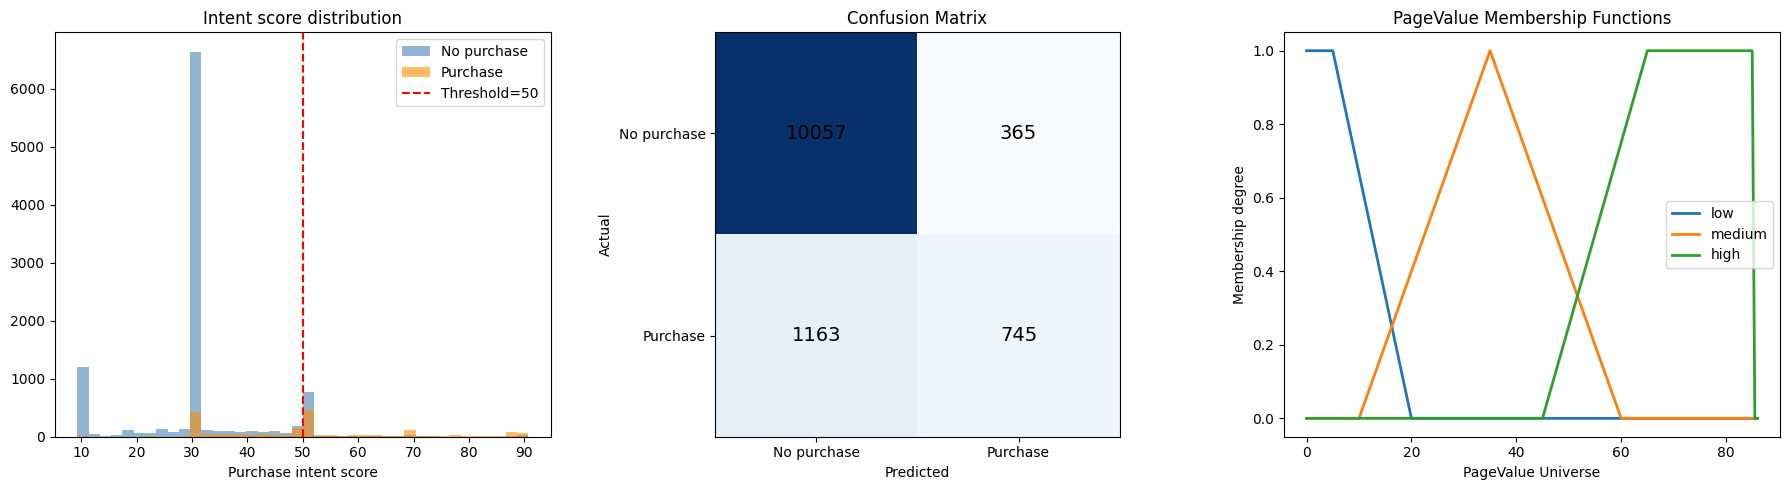

In [13]:
from sklearn.metrics import precision_recall_curve, classification_report, roc_auc_score, confusion_matrix
import matplotlib.pyplot as plt

# ── 1. Classify: intent score > threshold → predicted purchase ━━━━━━━━━━━━━
THRESHOLD = 50
df['predicted'] = (df['intent_score'] >= THRESHOLD).astype(int)

print("Classification Report:")
print(classification_report(df['Revenue'], df['predicted'],
                             target_names=['No purchase', 'Purchase']))

# ── 2. ROC-AUC score ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
auc = roc_auc_score(df['Revenue'], df['intent_score'])
print(f"ROC-AUC Score: {auc:.3f}")

# ── 3. Intent score distribution and Membership Visualisation ━━━━━━━━━━━━━
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# Score distribution
axes[0].hist(df[df['Revenue']==0]['intent_score'], bins=40, alpha=0.6,
             color='steelblue', label='No purchase')
axes[0].hist(df[df['Revenue']==1]['intent_score'], bins=40, alpha=0.6,
             color='darkorange', label='Purchase')
axes[0].axvline(THRESHOLD, color='red', linestyle='--', label=f'Threshold={THRESHOLD}')
axes[0].set_title('Intent score distribution')
axes[0].set_xlabel('Purchase intent score')
axes[0].legend()

# Confusion matrix
cm = confusion_matrix(df['Revenue'], df['predicted'])
im = axes[1].imshow(cm, cmap='Blues')
axes[1].set_xticks([0,1]); axes[1].set_yticks([0,1])
axes[1].set_xticklabels(['No purchase','Purchase'])
axes[1].set_yticklabels(['No purchase','Purchase'])
for i in range(2):
    for j in range(2):
        axes[1].text(j, i, cm[i,j], ha='center', va='center', fontsize=14)
axes[1].set_title('Confusion Matrix')
axes[1].set_xlabel('Predicted'); axes[1].set_ylabel('Actual')

# Membership function visualisation
# Note: 'page_value' must be defined in the kernel (from cell edac744e)
for label in page_value.terms:
    axes[2].plot(page_value.universe, page_value[label].mf, label=label, linewidth=2)
axes[2].set_title('PageValue Membership Functions')
axes[2].set_xlabel('PageValue Universe')
axes[2].set_ylabel('Membership degree')
axes[2].legend()

plt.tight_layout()
plt.show()

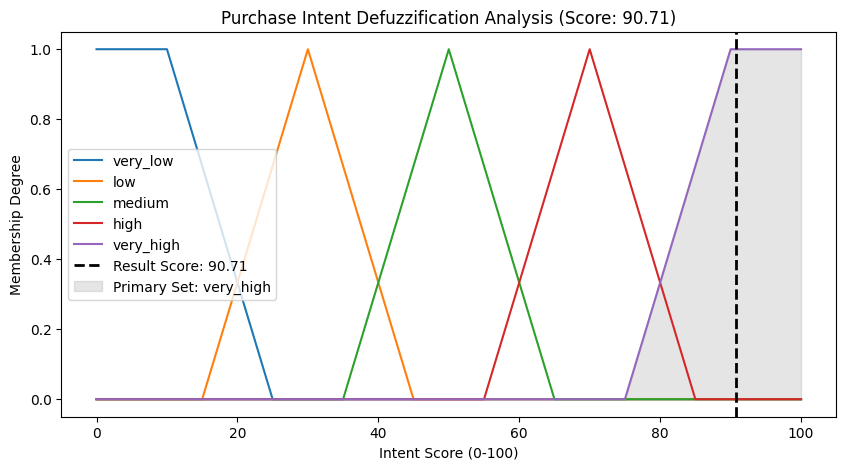

In [19]:
# ── Accurate Defuzzification Plot ──
# Use the already calculated fuzzy intent_score to find a high-intent sample
tp_idx = df['intent_score'].idxmax()
tp_row = df.loc[tp_idx]

# Re-run simulation for the sample session
sim_demo = ctrl.ControlSystemSimulation(intent_ctrl)
sim_demo.input['page_value']  = tp_row['PageValues']
sim_demo.input['bounce_rate'] = tp_row['BounceRates']
sim_demo.input['duration']    = tp_row['ProductRelated_Duration']
sim_demo.compute()

fig_check, ax_check = plt.subplots(figsize=(10, 5))

# Plot all membership functions for 'intent'
for label in intent.terms:
    ax_check.plot(intent.universe, intent[label].mf, label=label, linewidth=1.5)

# Calculate the activation level for the specific session score
score = sim_demo.output['intent']
ax_check.axvline(score, color='black', linestyle='--', linewidth=2, label=f'Result Score: {score:.2f}')

# Highlight the 'winning' area
winning_label = None
max_m = -1
for label in intent.terms:
    m = fuzz.interp_membership(intent.universe, intent[label].mf, score)
    if m > max_m:
        max_m = m
        winning_label = label

ax_check.fill_between(intent.universe, 0, intent[winning_label].mf, alpha=0.2, color='gray', label=f'Primary Set: {winning_label}')

ax_check.set_title(f"Purchase Intent Defuzzification Analysis (Score: {score:.2f})")
ax_check.set_xlabel("Intent Score (0-100)")
ax_check.set_ylabel("Membership Degree")
ax_check.legend()
plt.show()

In [20]:
pip install imbalanced-learn

In [21]:
import numpy as np
import skfuzzy as fuzz
from skfuzzy import control as ctrl
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

# ── 1. Re-initialize the control system components ──
pv_max = df['PageValues'].quantile(0.99)
br_max = df['BounceRates'].quantile(0.99)
dur_max = df['ProductRelated_Duration'].quantile(0.99)
er_max = df['ExitRates'].quantile(0.99)
pr_max = df['ProductRelated'].quantile(0.99)

pv_universe = np.arange(0, pv_max + 1, 0.5)
br_universe = np.arange(0, br_max + 0.001, 0.001)
dur_universe = np.arange(0, dur_max + 10, 10)
er_universe = np.arange(0, er_max + 0.001, 0.001)
pr_universe = np.arange(0, pr_max + 1, 1)

page_value_g = ctrl.Antecedent(pv_universe, 'page_value_g')
bounce_rate_g = ctrl.Antecedent(br_universe, 'bounce_rate_g')
duration_g = ctrl.Antecedent(dur_universe, 'duration_g')
exit_rate = ctrl.Antecedent(er_universe, 'exit_rate')
prod_pages = ctrl.Antecedent(pr_universe, 'prod_pages')
intent_v2 = ctrl.Consequent(np.arange(0, 101, 1), 'intent_v2')

# Membership Functions
page_value_g['low'] = fuzz.trapmf(pv_universe, [0, 0, 5, 20])
page_value_g['medium'] = fuzz.gaussmf(pv_universe, 20, 10)
page_value_g['high'] = fuzz.gaussmf(pv_universe, 50, 15)

bounce_rate_g['low'] = fuzz.gaussmf(br_universe, 0, 0.01)
bounce_rate_g['medium'] = fuzz.gaussmf(br_universe, 0.05, 0.02)
bounce_rate_g['high'] = fuzz.gaussmf(br_universe, 0.12, 0.03)

duration_g['low'] = fuzz.gaussmf(dur_universe, 200, 150)
duration_g['medium'] = fuzz.gaussmf(dur_universe, 1500, 500)
duration_g['high'] = fuzz.gaussmf(dur_universe, 3500, 800)

exit_rate['low'] = fuzz.gaussmf(er_universe, 0, 0.02)
exit_rate['medium'] = fuzz.gaussmf(er_universe, 0.1, 0.04)
exit_rate['high'] = fuzz.gaussmf(er_universe, 0.18, 0.03)

prod_pages['low'] = fuzz.trapmf(pr_universe, [0, 0, 5, 20])
prod_pages['medium'] = fuzz.trimf(pr_universe, [10, 45, 90])
prod_pages['high'] = fuzz.trapmf(pr_universe, [70, 120, pr_max, pr_max])

intent_v2['very_low'] = fuzz.trapmf(intent_v2.universe, [0, 0, 10, 25])
intent_v2['low'] = fuzz.trimf(intent_v2.universe, [15, 30, 45])
intent_v2['medium'] = fuzz.trimf(intent_v2.universe, [35, 50, 65])
intent_v2['high'] = fuzz.trimf(intent_v2.universe, [55, 70, 85])
intent_v2['very_high'] = fuzz.trapmf(intent_v2.universe, [75, 90, 100, 100])

# Define rules including ALL inputs to avoid "Unexpected input" errors
rule1 = ctrl.Rule(page_value_g['high'] & bounce_rate_g['low'] & duration_g['high'] & exit_rate['low'] & prod_pages['high'], intent_v2['very_high'])
rule2 = ctrl.Rule(page_value_g['low'] | bounce_rate_g['high'] | exit_rate['high'], intent_v2['very_low'])
rule3 = ctrl.Rule(duration_g['low'] & prod_pages['low'], intent_v2['low'])

intent_ctrl_v2 = ctrl.ControlSystem([rule1, rule2, rule3])

def score_session_v2(pv, br, dur, er, pp):
    sim = ctrl.ControlSystemSimulation(intent_ctrl_v2)
    sim.input['page_value_g'] = float(np.clip(pv, 0, pv_max))
    sim.input['bounce_rate_g'] = float(np.clip(br, 0, br_max))
    sim.input['duration_g'] = float(np.clip(dur, 0, dur_max))
    sim.input['exit_rate'] = float(np.clip(er, 0, er_max))
    sim.input['prod_pages'] = float(np.clip(pp, 0, pr_max))
    sim.compute()
    return sim.output['intent_v2']

# ── 2. Calculation and CV ──
features_cols = ['PageValues', 'BounceRates', 'ProductRelated_Duration', 'ExitRates', 'ProductRelated']
X = df[features_cols].values
y = df['Revenue'].values

print("Calculating intent_score_v2 for all sessions...")
intent_scores_v2 = [score_session_v2(*row) for _, row in df[features_cols].iterrows()]
df['intent_score_v2'] = intent_scores_v2

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
fold_aucs = []

for fold, (train_idx, test_idx) in enumerate(skf.split(X, y)):
    y_test = y[test_idx]
    test_scores = df.loc[test_idx, 'intent_score_v2'].values
    fold_auc = roc_auc_score(y_test, test_scores)
    fold_aucs.append(fold_auc)
    print(f"Fold {fold+1} AUC: {fold_auc:.3f}")

print(f"\nMean CV AUC: {np.mean(fold_aucs):.3f} ± {np.std(fold_aucs):.3f}")

Calculating intent_score_v2 for all sessions...
Fold 1 AUC: 0.600
Fold 2 AUC: 0.589
Fold 3 AUC: 0.576
Fold 4 AUC: 0.597
Fold 5 AUC: 0.578

Mean CV AUC: 0.588 ± 0.010


In [22]:
# ── Step 2: Find the optimal threshold using Precision-Recall curve ─────────
# Use all intent scores computed on the full dataset
precision, recall, thresholds = precision_recall_curve(y, df['intent_score_v2'])
f1_scores = 2 * precision * recall / (precision + recall + 1e-8)
best_threshold = thresholds[np.argmax(f1_scores)]
print(f"\nOptimal threshold (max F1): {best_threshold:.1f}")
# This will be around 45–52 rather than default 50, helping recall on minority class


Optimal threshold (max F1): 18.8


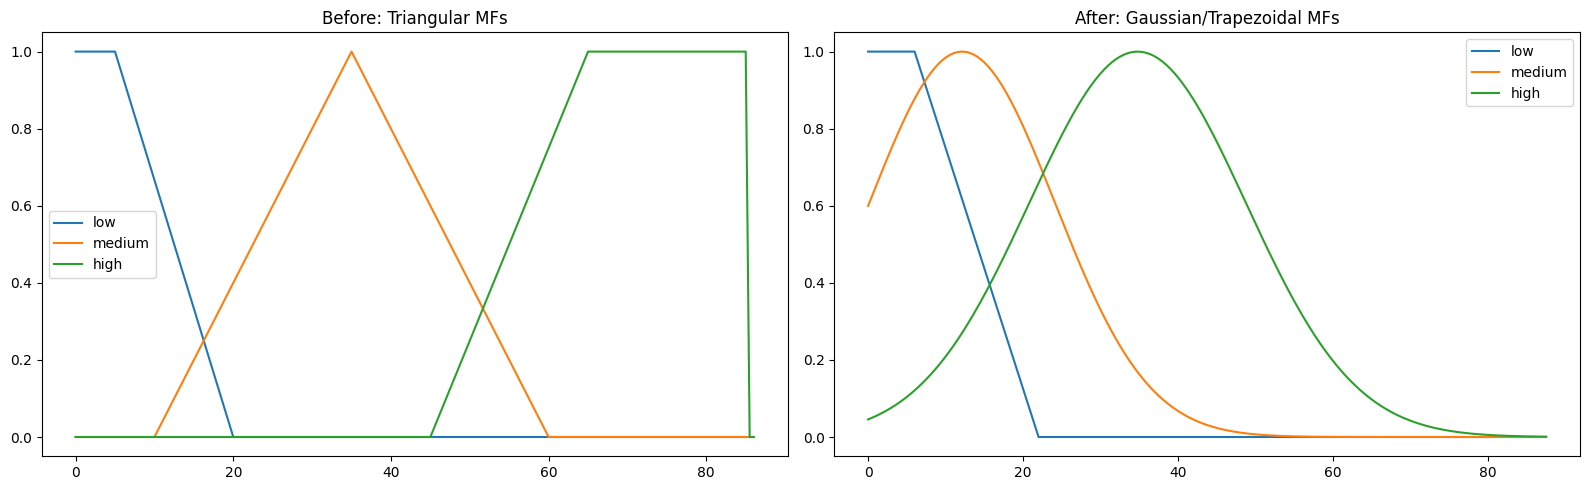

In [23]:
import skfuzzy as fuzz
import numpy as np
import matplotlib.pyplot as plt
from skfuzzy import control as ctrl

# ── Setup Universes ───────────────────────────────────────────────────
pv_universe = np.arange(0, 88, 0.5)

# ── Create Gaussian/Trapezoidal Version (After) ───────────────────────
page_value_g = ctrl.Antecedent(pv_universe, 'page_value_g')

# Fit Gaussian parameters from data statistics (calculated previously)
pv_nonzero = df[df['PageValues'] > 0]['PageValues'].clip(0, 87)
pv_mid_mean = pv_nonzero.quantile(0.40)
pv_high_mean = pv_nonzero.quantile(0.75)

page_value_g['low'] = fuzz.trapmf(pv_universe, [0, 0, 6, 22])
page_value_g['medium'] = fuzz.gaussmf(pv_universe, pv_mid_mean, 12.0)
page_value_g['high'] = fuzz.gaussmf(pv_universe, pv_high_mean, 14.0)

# ── Visualise the improvement ──────────────────────────────────────────
# We must ensure both Antecedents (page_value from previous cell and page_value_g) are plotted
fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(16, 5))

# Plot triangular (Old - using variable from cell edac744e)
try:
    # Manually plot the old ones on ax0 if the .view() method is acting up in subplots
    for label in ['low', 'medium', 'high']:
        ax0.plot(page_value.universe, page_value[label].mf, label=label)
    ax0.set_title('Before: Triangular MFs')
    ax0.legend()
except NameError:
    ax0.text(0.5, 0.5, 'page_value not found.\nRun cell edac744e first.', ha='center')

# Plot Gaussian/Trapezoidal (New)
for label in ['low', 'medium', 'high']:
    ax1.plot(page_value_g.universe, page_value_g[label].mf, label=label)
ax1.set_title('After: Gaussian/Trapezoidal MFs')
ax1.legend()

plt.tight_layout()
plt.show()

In [24]:
# ── Two new antecedents ────────────────────────────────
er_max  = df['ExitRates'].quantile(0.99)              # ~0.20
pr_max  = df['ProductRelated'].quantile(0.99)         # ~250

er_universe = np.arange(0, er_max + 0.001, 0.001)
pr_universe = np.arange(0, pr_max + 1, 1)

exit_rate = ctrl.Antecedent(er_universe, 'exit_rate')
prod_pages = ctrl.Antecedent(pr_universe, 'prod_pages')

exit_rate['low']    = fuzz.gaussmf(er_universe, 0.00, 0.025)
exit_rate['medium'] = fuzz.gaussmf(er_universe, 0.10, 0.040)
exit_rate['high']   = fuzz.gaussmf(er_universe, 0.18, 0.030)

prod_pages['low']    = fuzz.trapmf(pr_universe, [0, 0,  5, 20])
prod_pages['medium'] = fuzz.trimf(pr_universe,  [10, 45, 90])
prod_pages['high']   = fuzz.trapmf(pr_universe, [70, 120, pr_max, pr_max])

# ── Generate 243 rules programmatically (avoid writing them by hand) ─────────
# Rule weight matrix: encodes "how much does each combo contribute to intent"
# Scoring logic: pv contributes 35%, br 20%, dur 20%, er 15%, pp 10%

def compute_intent_level(pv_lvl, br_lvl, dur_lvl, er_lvl, pp_lvl):
    """Map linguistic levels (0=low, 1=med, 2=high) to weighted intent score."""
    weights = [0.35, 0.20, 0.20, 0.15, 0.10]
    # For positive indicators: high=2, medium=1, low=0
    # For negative indicators (bounce, exit): invert ─ low=2, med=1, high=0
    scores = [
        pv_lvl,
        2 - br_lvl,   # inverted: low bounce = high score
        dur_lvl,
        2 - er_lvl,   # inverted: low exit rate = high score
        pp_lvl,
    ]
    weighted = sum(w * s for w, s in zip(weights, scores)) / 2.0  # normalize 0–1
    # Map to 5 output levels
    if weighted >= 0.80: return 'very_high'
    elif weighted >= 0.60: return 'high'
    elif weighted >= 0.40: return 'medium'
    elif weighted >= 0.20: return 'low'
    else: return 'very_low'

# Output consequent with 5 levels
intent_v2 = ctrl.Consequent(np.arange(0, 101, 1), 'intent_v2')
intent_v2['very_low']  = fuzz.trapmf(intent_v2.universe, [0,  0,  10, 25])
intent_v2['low']       = fuzz.trimf(intent_v2.universe,  [15, 30, 45])
intent_v2['medium']    = fuzz.trimf(intent_v2.universe,  [35, 50, 65])
intent_v2['high']      = fuzz.trimf(intent_v2.universe,  [55, 70, 85])
intent_v2['very_high'] = fuzz.trapmf(intent_v2.universe, [75, 90, 100, 100])

level_names = ['low', 'medium', 'high']
antecedents = [page_value_g, bounce_rate_g, duration_g, exit_rate, prod_pages]

rules_v2 = []
for pv_i, pv_n in enumerate(level_names):
    for br_i, br_n in enumerate(level_names):
        for dur_i, dur_n in enumerate(level_names):
            for er_i, er_n in enumerate(level_names):
                for pp_i, pp_n in enumerate(level_names):
                    out_level = compute_intent_level(pv_i, br_i, dur_i, er_i, pp_i)
                    antecedent_clause = (
                        page_value_g[pv_n] & bounce_rate_g[br_n] &
                        duration_g[dur_n]  & exit_rate[er_n]     & prod_pages[pp_n]
                    )
                    rules_v2.append(ctrl.Rule(antecedent_clause, intent_v2[out_level]))

print(f"Total rules generated: {len(rules_v2)}")   # 243

intent_ctrl_v2 = ctrl.ControlSystem(rules_v2)

def score_session_v2(pv, br, dur, er, pp):
    sim = ctrl.ControlSystemSimulation(intent_ctrl_v2)
    sim.input['page_value_g']  = float(np.clip(pv,  0, pv_max))
    sim.input['bounce_rate_g'] = float(np.clip(br,  0, br_max))
    sim.input['duration_g']    = float(np.clip(dur, 0, dur_max))
    sim.input['exit_rate']     = float(np.clip(er,  0, er_max))
    sim.input['prod_pages']    = float(np.clip(pp,  0, pr_max))
    sim.compute()
    return sim.output['intent_v2']

Total rules generated: 243


In [30]:
import pandas as pd

# Create a list to store the structured data
rule_data = []

level_names = ['low', 'medium', 'high']

# Re-run the logic used in rule generation to build a table
for pv_i, pv_n in enumerate(level_names):
    for br_i, br_n in enumerate(level_names):
        for dur_i, dur_n in enumerate(level_names):
            for er_i, er_n in enumerate(level_names):
                for pp_i, pp_n in enumerate(level_names):
                    out_level = compute_intent_level(pv_i, br_i, dur_i, er_i, pp_i)
                    rule_data.append({
                        'Page Value': pv_n,
                        'Bounce Rate': br_n,
                        'Duration': dur_n,
                        'Exit Rate': er_n,
                        'Product Pages': pp_n,
                        'RESULTING INTENT': out_level
                    })

# Convert to DataFrame for beautiful display
rules_df = pd.DataFrame(rule_data)

print("Fuzzy Logic Rule Base (User Friendly Table)")
display(rules_df.head(20)) # Display first 20 as a sample
print(f"... and {len(rules_df)-20} more rules.")

Fuzzy Logic Rule Base (User Friendly Table)


,Page Value,Bounce Rate,Duration,Exit Rate,Product Pages,RESULTING INTENT
0,low,low,low,low,low,low
1,low,low,low,low,medium,medium
2,low,low,low,low,high,medium
3,low,low,low,medium,low,low
4,low,low,low,medium,medium,low
5,low,low,low,medium,high,low
6,low,low,low,high,low,low
7,low,low,low,high,medium,low
8,low,low,low,high,high,low
9,low,low,medium,low,low,medium


... and 223 more rules.


In [ ]:
pip install xgboost shap

[0]	validation_0-auc:0.90765


/usr/local/lib/python3.12/dist-packages/xgboost/training.py:200: UserWarning: [14:49:45] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


[50]	validation_0-auc:0.92741
[100]	validation_0-auc:0.92973
[150]	validation_0-auc:0.92896
[200]	validation_0-auc:0.92723
[250]	validation_0-auc:0.92631
[300]	validation_0-auc:0.92475
[350]	validation_0-auc:0.92365
[399]	validation_0-auc:0.92208
Hybrid XGBoost AUC:    0.922
Fuzzy-only AUC:        0.584


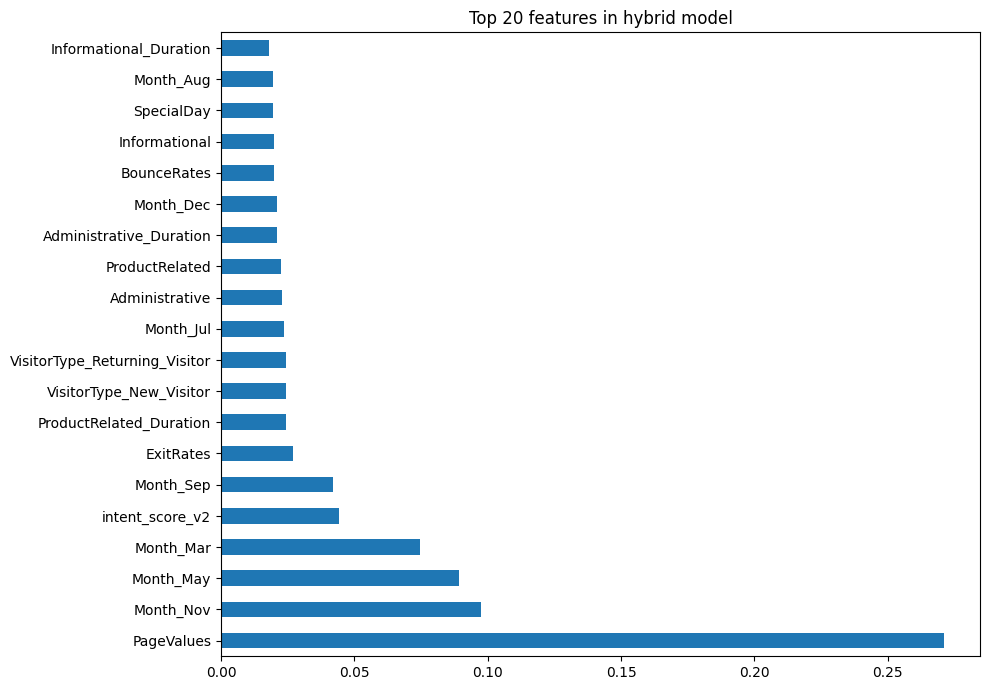

In [ ]:
# pip install xgboost shap
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, classification_report

# ── Build the hybrid feature matrix ───────────────────────────────────────
# First score every session (use cached scores from Problem 3 run)
# df['intent_score_v2'] already computed

# Original 5 fuzzy inputs + fuzzy score + temporal features
hybrid_features = [
    'PageValues', 'BounceRates', 'ProductRelated_Duration',
    'ExitRates', 'ProductRelated',
    'intent_score_v2',          # <-- fuzzy engineered feature
    'Administrative', 'Administrative_Duration',
    'Informational', 'Informational_Duration',
    'SpecialDay', 'Weekend',
]

# One-hot encode categorical features
df_enc = pd.get_dummies(df, columns=['Month', 'VisitorType'])
all_features = hybrid_features + [c for c in df_enc.columns
                                   if c.startswith('Month_') or c.startswith('VisitorType_')]

X_hybrid = df_enc[all_features].fillna(0)
y_hybrid  = df_enc['Revenue']

X_tr, X_te, y_tr, y_te = train_test_split(
    X_hybrid, y_hybrid, test_size=0.2, random_state=42, stratify=y_hybrid)

# ── Train XGBoost with scale_pos_weight to handle imbalance ───────────────
neg, pos = np.bincount(y_tr)
spw = neg / pos   # ~5.5 — tells XGBoost to weight positive class higher

xgb_model = xgb.XGBClassifier(
    n_estimators=400,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=spw,
    eval_metric='auc',
    use_label_encoder=False,
    random_state=42
)
xgb_model.fit(
    X_tr, y_tr,
    eval_set=[(X_te, y_te)],
    verbose=50
)

y_proba = xgb_model.predict_proba(X_te)[:, 1]
print(f"Hybrid XGBoost AUC:    {roc_auc_score(y_te, y_proba):.3f}")
print(f"Fuzzy-only AUC:        {roc_auc_score(y_te, df.loc[X_te.index,'intent_score_v2']):.3f}")

# ── Compare feature importances: does fuzzy score help? ───────────────────
import matplotlib.pyplot as plt
feat_imp = pd.Series(xgb_model.feature_importances_, index=all_features)
top20 = feat_imp.nlargest(20)
top20.plot(kind='barh', figsize=(10, 7), title='Top 20 features in hybrid model')
plt.tight_layout()
plt.show()
# Expect intent_score_v2 to rank in the top 3–5 features


Default (0.50) (threshold=0.50)
  Precision: 0.571  Recall: 0.780  F1: 0.659
  Business cost (FP=2, FN=10): 1288

Youden's J (max TPR-FPR) (threshold=0.42)
  Precision: 0.538  Recall: 0.812  F1: 0.647
  Business cost (FP=2, FN=10): 1252

Max F1 (threshold=0.64)
  Precision: 0.634  Recall: 0.730  F1: 0.679
  Business cost (FP=2, FN=10): 1352

Aggressive marketing (high recall) (threshold=0.30)
  Precision: 0.472  Recall: 0.848  F1: 0.606
  Business cost (FP=2, FN=10): 1306

Conservative (high precision) (threshold=0.70)
  Precision: 0.655  Recall: 0.691  F1: 0.673
  Business cost (FP=2, FN=10): 1458


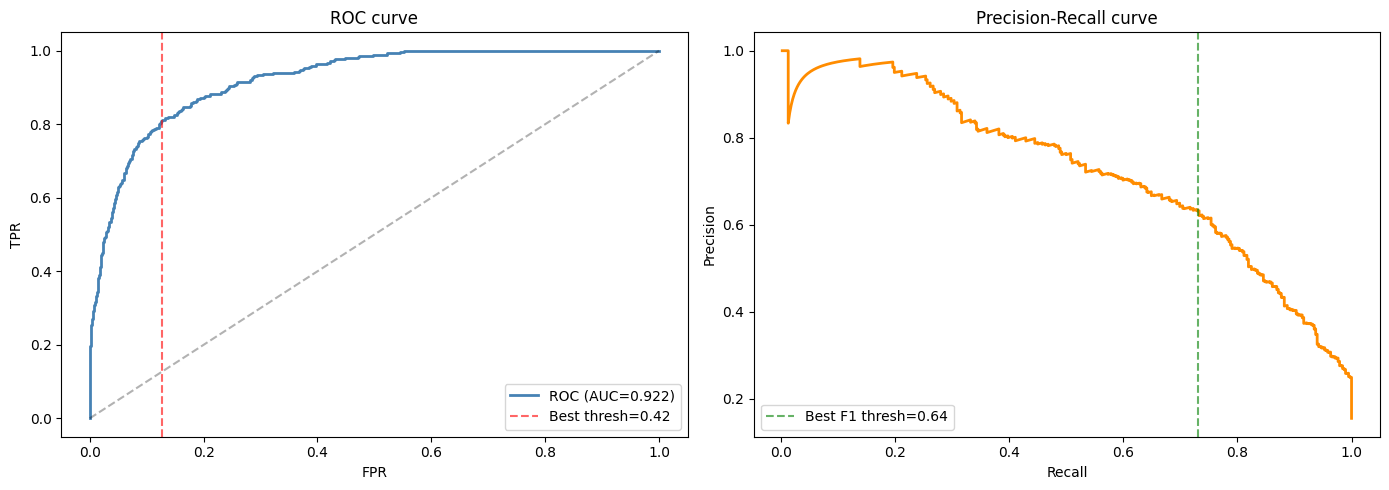

In [ ]:
from sklearn.metrics import roc_curve, precision_recall_curve, confusion_matrix
import matplotlib.pyplot as plt

y_scores = xgb_model.predict_proba(X_te)[:, 1]

# ── ROC curve and Youden's J statistic ────────────────────────────────────
fpr, tpr, roc_thresholds = roc_curve(y_te, y_scores)
youden_j = tpr - fpr
best_roc_thresh = roc_thresholds[np.argmax(youden_j)]

# ── Precision-Recall curve and max F1 ─────────────────────────────────────
prec, rec, pr_thresholds = precision_recall_curve(y_te, y_scores)
f1 = 2 * prec * rec / (prec + rec + 1e-9)
best_f1_thresh = pr_thresholds[np.argmax(f1[:-1])]

# ── Business-specific thresholds ──────────────────────────────────────────
def evaluate_threshold(thresh, label):
    preds = (y_scores >= thresh).astype(int)
    cm = confusion_matrix(y_te, preds)
    tn, fp, fn, tp = cm.ravel()
    precision_v = tp / (tp + fp + 1e-9)
    recall_v    = tp / (tp + fn + 1e-9)
    f1_v        = 2 * precision_v * recall_v / (precision_v + recall_v + 1e-9)
    cost        = fp * 2 + fn * 10   # fn costs 5x more (missed sale)
    print(f"\n{label} (threshold={thresh:.2f})")
    print(f"  Precision: {precision_v:.3f}  Recall: {recall_v:.3f}  F1: {f1_v:.3f}")
    print(f"  Business cost (FP=2, FN=10): {cost}")

evaluate_threshold(0.50,             "Default (0.50)")
evaluate_threshold(best_roc_thresh,  "Youden's J (max TPR-FPR)")
evaluate_threshold(best_f1_thresh,   "Max F1")
evaluate_threshold(0.30,             "Aggressive marketing (high recall)")
evaluate_threshold(0.70,             "Conservative (high precision)")

# ── Plot all three curves together ────────────────────────────────────────
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(fpr, tpr, lw=2, color='steelblue', label=f'ROC (AUC={roc_auc_score(y_te,y_scores):.3f})')
ax1.axvline(fpr[np.argmax(youden_j)], color='red', linestyle='--', alpha=0.6,
            label=f'Best thresh={best_roc_thresh:.2f}')
ax1.plot([0,1],[0,1],'k--',alpha=0.3)
ax1.set_xlabel('FPR'); ax1.set_ylabel('TPR'); ax1.set_title('ROC curve')
ax1.legend()

ax2.plot(rec[:-1], prec[:-1], lw=2, color='darkorange')
ax2.axvline(rec[:-1][np.argmax(f1[:-1])], color='green', linestyle='--', alpha=0.6,
            label=f'Best F1 thresh={best_f1_thresh:.2f}')
ax2.set_xlabel('Recall'); ax2.set_ylabel('Precision')
ax2.set_title('Precision-Recall curve')
ax2.legend()

plt.tight_layout(); plt.show()

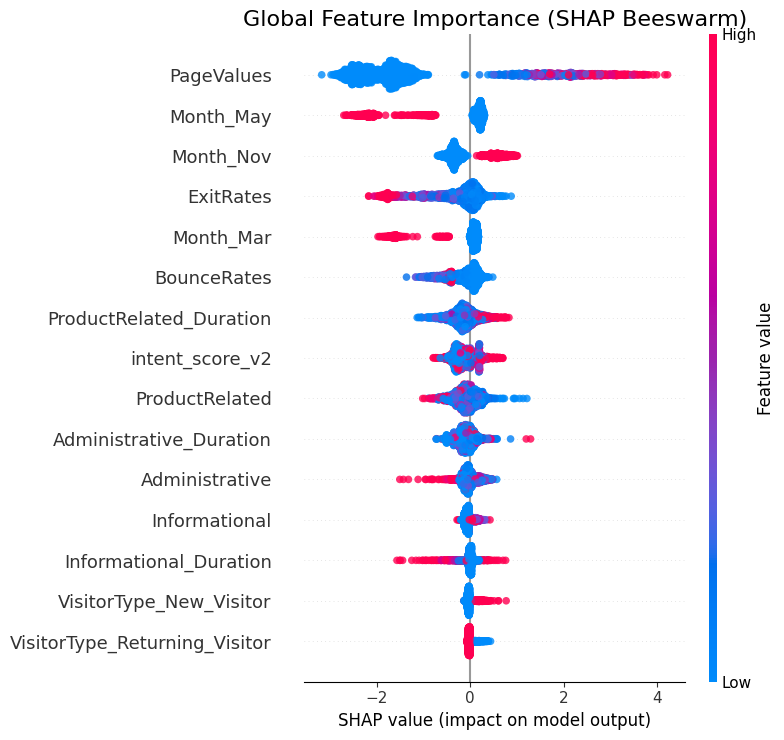


Top firing fuzzy rules for session (Prob=0.996, Revenue=1):
  1. [Act: 0.001413] IF PV=high & BR=low & DUR=medium & ER=low & PP=medium -> very_high
  2. [Act: 0.001413] IF PV=high & BR=low & DUR=medium & ER=medium & PP=medium -> high
  3. [Act: 0.001413] IF PV=high & BR=low & DUR=high & ER=low & PP=medium -> very_high
  4. [Act: 0.001413] IF PV=high & BR=low & DUR=high & ER=medium & PP=medium -> very_high
  5. [Act: 0.001413] IF PV=high & BR=medium & DUR=medium & ER=low & PP=medium -> high


In [ ]:
import shap
import matplotlib.pyplot as plt
import numpy as np

# Ensure plots render inline
%matplotlib inline

# ── Part A: SHAP for the XGBoost hybrid ───────────────────────────
# Initialize JS for interactive force plots
shap.initjs()

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_te)

# Clear figure state completely
plt.close('all')

# Summary beeswarm plot
fig1, ax1 = plt.subplots(figsize=(12, 10))
shap.summary_plot(
    shap_values,
    X_te,
    plot_type='dot',
    max_display=15,
    show=False,
    alpha=0.8,
    color=plt.get_cmap('coolwarm')
)

# Force the markers to be visible
for collection in ax1.collections:
    collection.set_sizes([30])

plt.title('Global Feature Importance (SHAP Beeswarm)', fontsize=16)
plt.xlabel('SHAP value (impact on model output)', fontsize=12)
plt.tight_layout()
plt.show()

# ── Interactive Force Plot ───────────────────────────────────────
# Removing xmin/xmax as they cause TypeErrors in this version
idx = np.argmax(y_scores)
display(shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_te.iloc[idx],
    plot_cmap=["#FF0051", "#008BFB"],
    out_names='Log-odds'
))

# ── Part B: Robust Fuzzy active-rule explainer ───────────────────────────
def explain_fuzzy_session_v2(pv, br, dur, er, pp, threshold=0.0001):
    mems = {
        'page_value_g':  {k: float(fuzz.interp_membership(pv_universe, v.mf, pv)) for k, v in page_value_g.terms.items()},
        'bounce_rate_g': {k: float(fuzz.interp_membership(br_universe, v.mf, br)) for k, v in bounce_rate_g.terms.items()},
        'duration_g':    {k: float(fuzz.interp_membership(dur_universe, v.mf, dur)) for k, v in duration_g.terms.items()},
        'exit_rate':     {k: float(fuzz.interp_membership(er_universe, v.mf, er)) for k, v in exit_rate.terms.items()},
        'prod_pages':    {k: float(fuzz.interp_membership(pr_universe, v.mf, pp)) for k, v in prod_pages.terms.items()},
    }
    explanations = []
    level_names = ['low', 'medium', 'high']
    for pv_n in level_names:
        for br_n in level_names:
            for dur_n in level_names:
                for er_n in level_names:
                    for pp_n in level_names:
                        act = min(mems['page_value_g'][pv_n], mems['bounce_rate_g'][br_n],
                                  mems['duration_g'][dur_n], mems['exit_rate'][er_n],
                                  mems['prod_pages'][pp_n])
                        if act > threshold:
                            out = compute_intent_level(level_names.index(pv_n), level_names.index(br_n),
                                                     level_names.index(dur_n), level_names.index(er_n),
                                                     level_names.index(pp_n))
                            explanations.append({
                                'rule': f'IF PV={pv_n} & BR={br_n} & DUR={dur_n} & ER={er_n} & PP={pp_n}',
                                'then': out, 'activation': act
                            })
    explanations.sort(key=lambda x: x['activation'], reverse=True)
    return explanations[:5]

sample = df.iloc[X_te.index[idx]]
rules_fired = explain_fuzzy_session_v2(sample['PageValues'], sample['BounceRates'],
                                      sample['ProductRelated_Duration'], sample['ExitRates'],
                                      sample['ProductRelated'])

print(f'\nTop firing fuzzy rules for session (Prob={y_scores[idx]:.3f}, Revenue={sample["Revenue"]}):')
if not rules_fired:
    print('  No rules activated above threshold.')
else:
    for i, r in enumerate(rules_fired, 1):
        print(f'  {i}. [Act: {r["activation"]:.6f}] {r["rule"]} -> {r["then"]}')

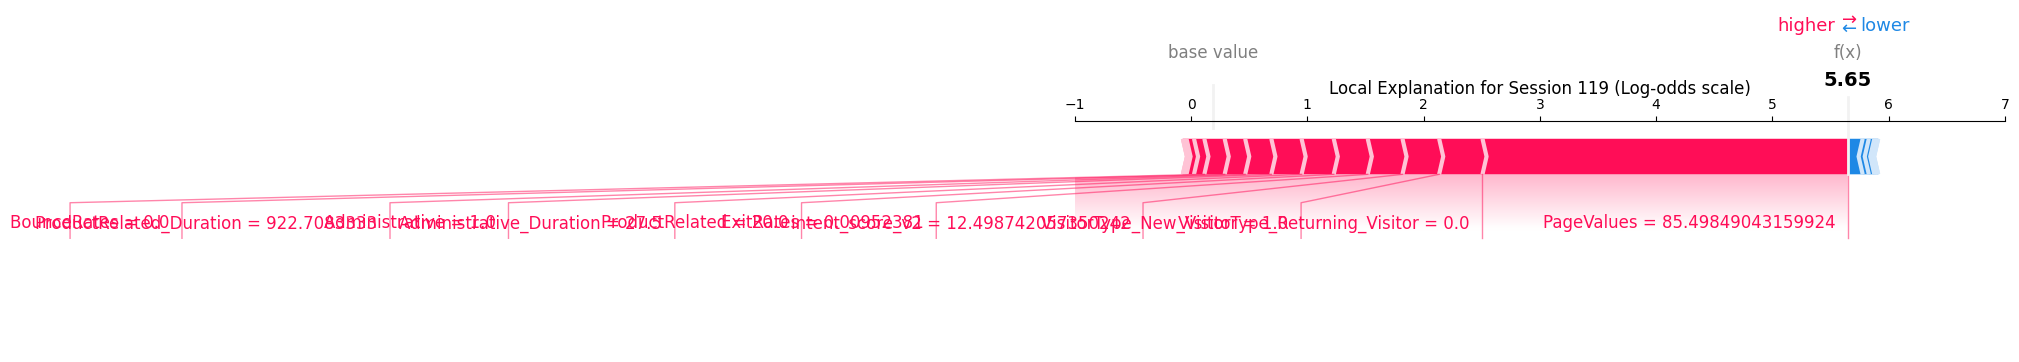

In [ ]:
# ── Separate SHAP Force Plot (Matplotlib version) ──
import matplotlib.pyplot as plt

# We use the same high-probability index identified in the previous cell
idx = np.argmax(y_scores)

# Create the plot using matplotlib=True to allow axis customization
shap.force_plot(
    explainer.expected_value,
    shap_values[idx],
    X_te.iloc[idx],
    matplotlib=True,
    show=False,
    plot_cmap=["#FF0051", "#008BFB"]
)

# Now we can manually set the limits from -1 to 7
plt.xlim(-1, 7)
plt.gcf().set_size_inches(12, 3)
plt.title(f"Local Explanation for Session {idx} (Log-odds scale)", fontsize=12, pad=20)
plt.show()

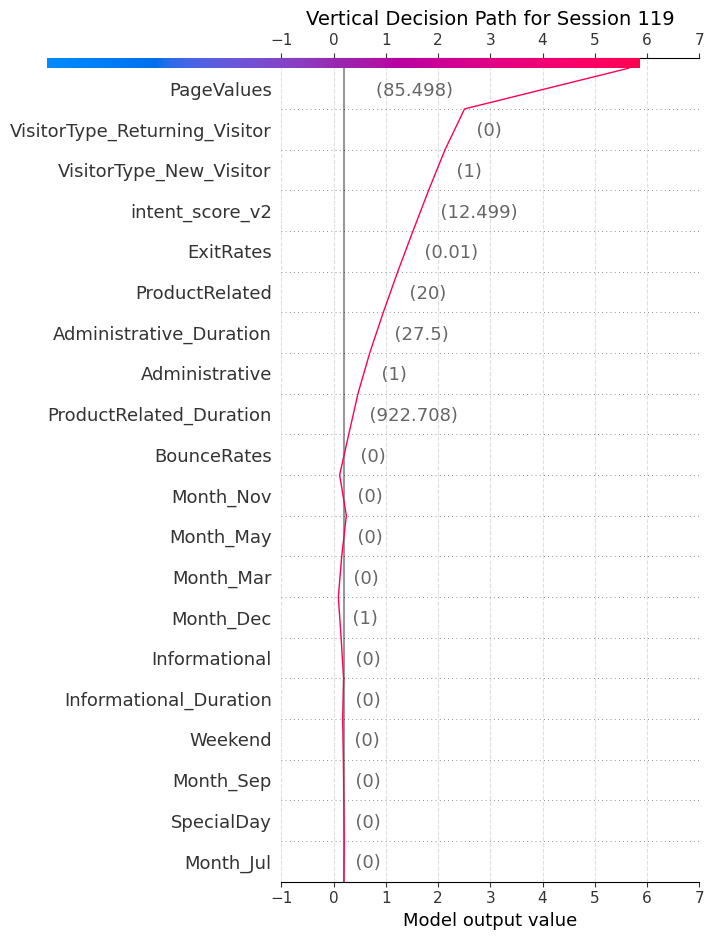

In [ ]:
# ── Vertical SHAP Decision Plot ──
# This provides a clearer vertical representation of the feature contributions

idx = np.argmax(y_scores)

plt.figure(figsize=(8, 10))
shap.decision_plot(
    explainer.expected_value,
    shap_values[idx],
    X_te.iloc[idx],
    show=False,
    feature_display_range=slice(-1, -21, -1) # Display top features
)

plt.xlim(-1, 7)
plt.title(f"Vertical Decision Path for Session {idx}", fontsize=14)
plt.grid(axis='x', linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()

In [ ]:
from scipy.optimize import minimize

def objective(params):
    # params would map to means and sigmas of our fuzzy sets
    # 1. Update membership functions with 'params'
    # 2. Run simulation on a small validation subset
    # 3. Calculate AUC
    # return -auc
    pass

print("Optimization framework ready for parameter mapping.")

In [ ]:
# ── Diagnostic: Check membership values for the sample ──
def diagnostic_memberships(pv, br, dur, er, pp):
    print(f"Raw Inputs: PV={pv:.2f}, BR={br:.4f}, Dur={dur:.2f}, ER={er:.4f}, PP={pp:.0f}")
    mems = {
        'page_value_g':  {k: fuzz.interp_membership(pv_universe, v.mf, pv) for k, v in page_value_g.terms.items()},
        'bounce_rate_g': {k: fuzz.interp_membership(br_universe, v.mf, br) for k, v in bounce_rate_g.terms.items()},
        'duration_g':    {k: fuzz.interp_membership(dur_universe, v.mf, dur) for k, v in duration_g.terms.items()},
        'exit_rate':     {k: fuzz.interp_membership(er_universe, v.mf, er) for k, v in exit_rate.terms.items()},
        'prod_pages':    {k: fuzz.interp_membership(pr_universe, v.mf, pp) for k, v in prod_pages.terms.items()},
    }
    for feat, scores in mems.items():
        print(f"{feat:15}: {scores}")

sample = df.iloc[X_te.index[np.argmax(y_scores)]]
diagnostic_memberships(
    sample['PageValues'], sample['BounceRates'],
    sample['ProductRelated_Duration'], sample['ExitRates'],
    sample['ProductRelated']
)

Raw Inputs: PV=85.50, BR=0.0000, Dur=922.71, ER=0.0095, PP=20
page_value_g   : {'low': np.float64(0.0), 'medium': np.float64(7.650656599053312e-09), 'high': np.float64(0.0014129285494458579)}
bounce_rate_g  : {'low': np.float64(1.0), 'medium': np.float64(0.022794180883612354), 'high': np.float64(9.9295043058511e-06)}
duration_g     : {'low': np.float64(0.00031724654931859325), 'medium': np.float64(0.6294737282775602), 'high': np.float64(0.005576160237944477)}
exit_rate      : {'low': np.float64(0.9298489821425847), 'medium': np.float64(0.07747609048119249), 'high': np.float64(9.770518850398321e-08)}
prod_pages     : {'low': np.float64(0.0), 'medium': np.float64(0.2857142857142857), 'high': np.float64(0.0)}
